In [24]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

In [25]:
#load data
df1 = pd.read_csv("../dataset/train.csv")
df2 = pd.read_csv("../dataset/test.csv")

X_train = df1.drop(columns = ['Churn'])
y_train = df1['Churn']

X_test = df2.drop(columns = ['Churn'])
y_test = df2['Churn']


In [26]:
y_train = y_train.map({'No': 0, 'Yes': 1})
y_test = y_test.map({'No': 0, 'Yes': 1})

In [27]:
#check datatypes
X_train.dtypes

gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [28]:
#check column size
print(X_train.shape)
print(X_test.shape)

(5625, 19)
(1407, 19)


In [29]:
#Encoding (One-hot)
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
#Check the size again
print(X_train.shape)
print(X_test.shape)

(5625, 46)
(1407, 46)


In [42]:
#Sample KNN model
knn_model = KNeighborsClassifier(n_neighbors = 11) #Set K = 11
#train
knn_model.fit(X_train,y_train)
#test
y_pred_knn = knn_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Report:\n", classification_report(y_test, y_pred_knn))

Accuracy: 0.7867803837953091
KNN Report:
               precision    recall  f1-score   support

           0       0.81      0.92      0.86      1033
           1       0.66      0.41      0.51       374

    accuracy                           0.79      1407
   macro avg       0.73      0.67      0.69      1407
weighted avg       0.77      0.79      0.77      1407



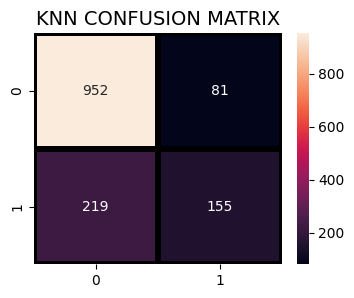

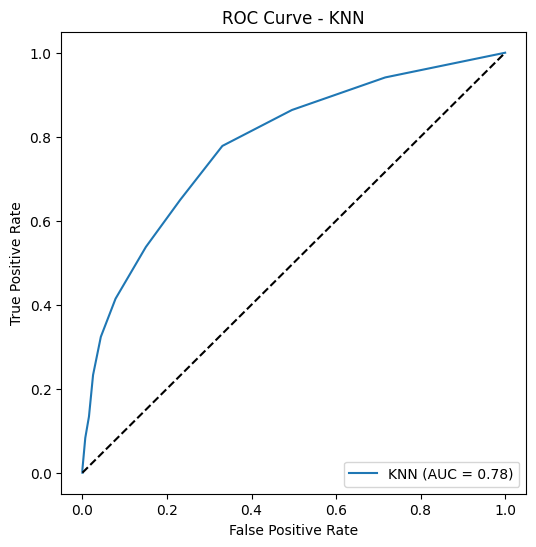

In [44]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title("KNN CONFUSION MATRIX",fontsize=14)
plt.show()

y_prob_knn = knn_model.predict_proba(X_test)[:, 1]
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)
plt.figure(figsize=(6,6))
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend(loc="lower right")
plt.show()


In [45]:
#Add Scale
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Upgrade model
knn_model_new = KNeighborsClassifier(
    n_neighbors=7,        #K = 7
    weights='distance',   
    metric='manhattan'   
)

knn_model_new.fit(X_train_scaled, y_train)

y_pred = knn_model_new.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7420042643923241
              precision    recall  f1-score   support

           0       0.81      0.84      0.83      1033
           1       0.52      0.47      0.49       374

    accuracy                           0.74      1407
   macro avg       0.67      0.66      0.66      1407
weighted avg       0.74      0.74      0.74      1407



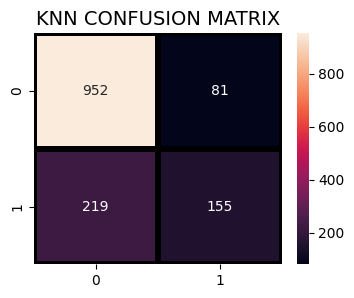

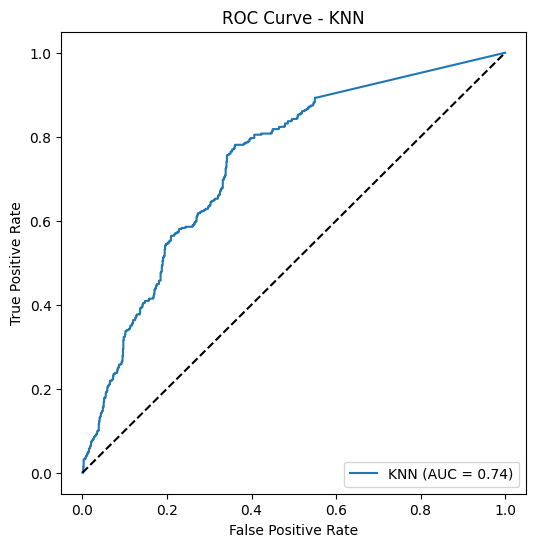

In [46]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title("KNN CONFUSION MATRIX",fontsize=14)
plt.show()

y_prob_knn = knn_model_new.predict_proba(X_test)[:, 1]
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)
plt.figure(figsize=(6,6))
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend(loc="lower right")
plt.show()